<a href="https://colab.research.google.com/github/farahnda/Learning/blob/main/KNN_for_Anomaly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

In [7]:
data = pd.read_csv('https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv')
df = data[['sepal_length', 'sepal_width']] # CUMA PAKE 2 KOLOM

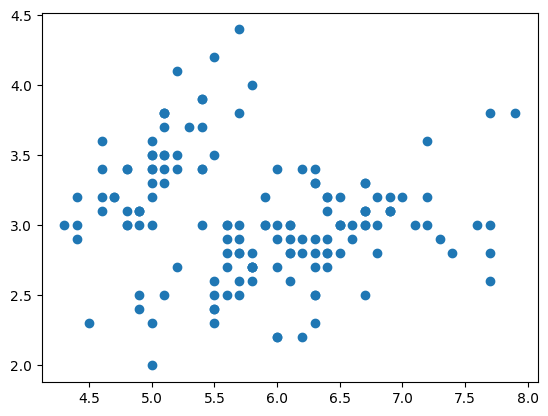

In [8]:
plt.scatter(df['sepal_length'], df['sepal_width']) # BUAT SEBARAN DATA

In [10]:
X = df.values # MASUKKIN NILAI KOLOM KE X
nbrs = NearestNeighbors(n_neighbors=3) # PAKE MODEL KNN, dgn 3 data terdekat
nbrs.fit(X) # BELAJAR

NearestNeighbors(n_neighbors=3)

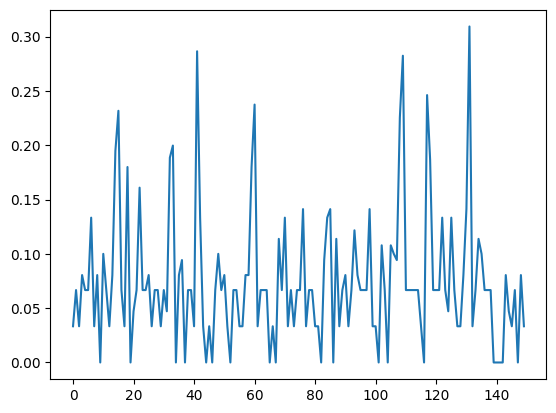

In [12]:
distances, indexes = nbrs.kneighbors(X) # KALKULASI JARAK & INDEKS DARI KNN
plt.plot(distances.mean(axis=1)) # DI ATAS 0.15 = ANOMALI
# mean(axis=1): buat merata2 angka secara horizontal
# SB X = INDEX DATA, SB Y = RATA2 JARAK KE TETANGGA TERDEKAT

In [13]:
outlier_index = np.where(distances.mean(axis=1) > 0.15)
outlier_index # ARRAY YANG PUNYA ANOMALI

(array([ 14,  15,  18,  22,  32,  33,  41,  59,  60, 108, 109, 117, 118,
        131]),)

In [16]:
outlier_values = df.iloc[outlier_index]
outlier_values

,sepal_length,sepal_width
14,5.8,4.0
15,5.7,4.4
18,5.7,3.8
22,4.6,3.6
32,5.2,4.1
33,5.5,4.2
41,4.5,2.3
59,5.2,2.7
60,5.0,2.0
108,6.7,2.5


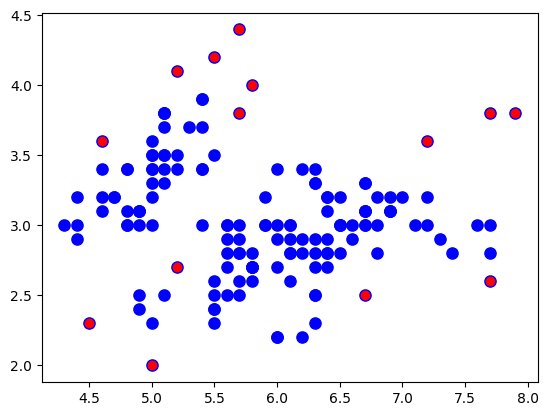

In [18]:
plt.scatter(df['sepal_length'], df['sepal_width'], color='b', s=65)
plt.scatter(outlier_values['sepal_length'], outlier_values['sepal_width'], color='r')